<a href="https://colab.research.google.com/github/nikhitha2007/ML-SKILL/blob/main/10_Heart_Disease_XGBoost_LightGBM_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HEART DISEASE - ADVANCED ML & SHAP

First five rows:
   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  

Dataset shape: (303, 14)

Target classes: [1, 0]
Feature count: 13

MODEL COMPARISON
   Model  Accuracy
 XGBoost  0.803279
LightGBM  0.803279

XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        33
           1       0.83      0.71      0.77        28

  

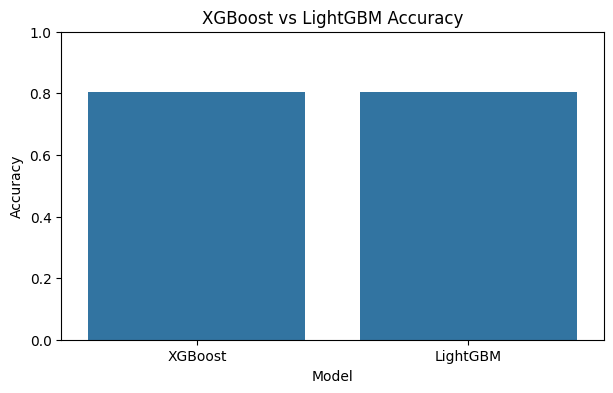

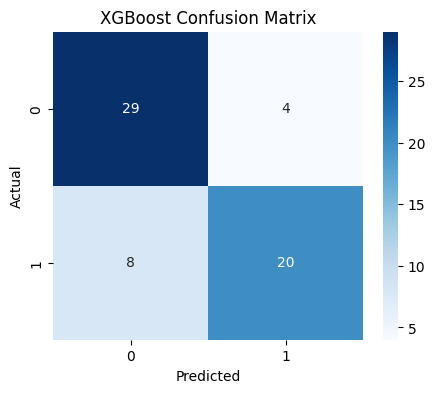


Generating SHAP explanations...


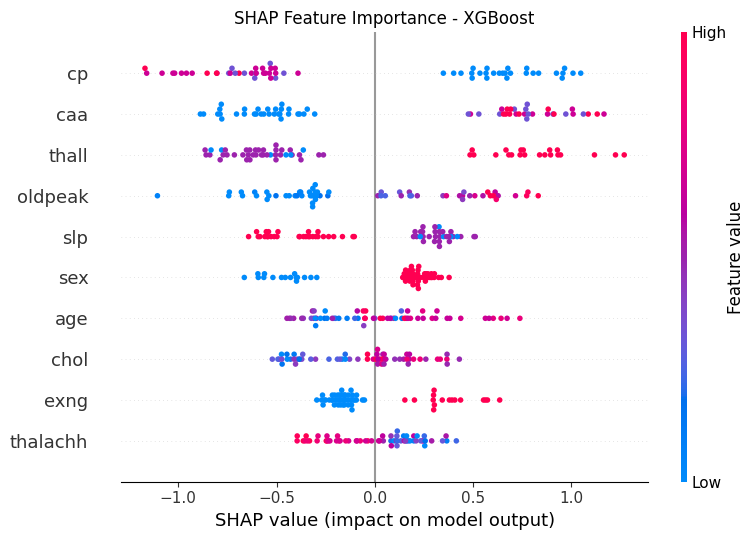


Saved model comparison and predictions as CSV files.
PROGRAM 10 COMPLETED SUCCESSFULLY!


In [1]:

# PROGRAM 10: HEART DISEASE - XGBOOST, LIGHTGBM & SHAP

# 1. Install required libraries
%pip -q install xgboost lightgbm shap

# 2. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

print("HEART DISEASE - ADVANCED ML & SHAP")
print("=" * 55)

# 3. Load the dataset
url = "https://raw.githubusercontent.com/ramtinmt/heart-disease-classification/main/heart.csv"
df = pd.read_csv(url)

print("\nFirst five rows:")
print(df.head())
print("\nDataset shape:", df.shape)

# 4. Identify the target column
possible_targets = [
    "target", "output", "disease", "HeartDisease", "heart_disease"
]
target_col = next(
    (col for col in possible_targets if col in df.columns),
    None
)

if target_col is None:
    raise ValueError(
        "Target column not found. Available columns: "
        + str(df.columns.tolist())
    )

df = df.dropna(subset=[target_col]).copy()

X = df.drop(columns=[target_col])
y = df[target_col]

# Encode categorical input columns
X = pd.get_dummies(X, drop_first=False)
X = X.replace([np.inf, -np.inf], np.nan)

# Convert target to numeric class labels
y, class_labels = pd.factorize(y)

if len(class_labels) < 2:
    raise ValueError("The dataset must contain at least two target classes.")

# Fill missing feature values using column medians
X = X.fillna(X.median()).astype(float)

print("\nTarget classes:", list(class_labels))
print("Feature count:", X.shape[1])

# 5. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 6. Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss",
    n_jobs=2
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# 7. Train LightGBM
lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)

# 8. Compare model performance
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "Accuracy": [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgb_pred)
    ]
})

print("\nMODEL COMPARISON")
print(results.to_string(index=False))

print("\nXGBOOST CLASSIFICATION REPORT")
print(classification_report(
    y_test, xgb_pred, zero_division=0
))

print("\nLIGHTGBM CLASSIFICATION REPORT")
print(classification_report(
    y_test, lgb_pred, zero_division=0
))

# ROC-AUC for binary classification
if len(np.unique(y)) == 2:
    print("XGBoost ROC-AUC:",
          round(roc_auc_score(
              y_test, xgb_model.predict_proba(X_test)[:, 1]
          ), 4))

    print("LightGBM ROC-AUC:",
          round(roc_auc_score(
              y_test, lgb_model.predict_proba(X_test)[:, 1]
          ), 4))

# 9. Plot model accuracy
plt.figure(figsize=(7, 4))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("XGBoost vs LightGBM Accuracy")
plt.ylim(0, 1)
plt.show()

# 10. XGBoost confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, xgb_pred),
    annot=True, fmt="d", cmap="Blues"
)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 11. Explain XGBoost predictions using SHAP
print("\nGenerating SHAP explanations...")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Support both binary and multiclass SHAP outputs
if isinstance(shap_values, list):
    values_to_plot = shap_values[-1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    values_to_plot = shap_values[:, :, -1]
else:
    values_to_plot = shap_values

plt.figure()
shap.summary_plot(
    values_to_plot,
    X_test,
    max_display=10,
    show=False
)
plt.title("SHAP Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

# 12. Save model comparison and predictions
results.to_csv("heart_disease_model_comparison.csv", index=False)

predictions = pd.DataFrame({
    "Actual": y_test,
    "XGBoost_Predicted": xgb_pred,
    "LightGBM_Predicted": lgb_pred
})
predictions.to_csv("heart_disease_advanced_predictions.csv", index=False)

print("\nSaved model comparison and predictions as CSV files.")
print("PROGRAM 10 COMPLETED SUCCESSFULLY!")